# Notebook 5 - Learned Decoding: a Graph Neural Network Decoder

*Part of **QEC Explorer**, and the bridge to the research this project connects to. In Notebooks 2 and 3 we watched **belief propagation fail** on the surface code - it has no threshold here. The frontier response is to **learn** a decoder from data. This notebook builds a small but real **graph neural network (GNN)** decoder in PyTorch, trains it on synthetic noise, and compares it to classical baselines - honestly.*

This is the notebook where we connect to current research: **AlphaQubit** (Google, 2024) and a wave of neural decoders are exactly this idea at scale. We run the experiment twice:

1. **Our hand formulation** - a GNN on the Tanner graph predicting per-qubit flips, judged against the hand-built BP from Notebook 2. Honest result: at $d=3$ with minutes of CPU training, it does **not** beat BP.
2. **The professional formulation** - the way real neural-decoder papers (and AlphaQubit) pose the task: train on **Stim's circuit-level detector data** to predict the **logical observable flip**, and benchmark against **PyMatching's MWPM**, the industry-standard baseline. There the GNN goes from useless to genuinely decoding - and we measure exactly how much of the gap to MWPM it closes.

> ### Built on PyTorch + Stim + PyMatching
> This is a QEC Explorer spin-off notebook. The neural network is **[PyTorch](https://pytorch.org)** (Meta AI, BSD). Section 7 generates training data with **[Stim](https://github.com/quantumlib/Stim)** (Google Quantum AI, Apache-2.0) - the same circuit-level sampler used in Notebook 3's threshold measurement - and benchmarks against **[PyMatching](https://github.com/oscarhiggott/PyMatching)** (Oscar Higgott, Apache-2.0). Data from Stim's detector sampler with an MWPM baseline is *exactly* the published recipe for GNN decoders (Lange et al., 2023).

> **What's genuinely real here:** both models train (you'll see the loss curves fall), and every comparison uses identical test data. **What we're honest about:** at this scale neither learned model beats its classical baseline. We explain why, and what a real (much larger) model does differently.

---
## 1 - Reuse the verified physics + BP baseline (verbatim from Notebook 2)

In [1]:
# Colab / fresh-environment setup. Safe to re-run.
try:
    import torch, stim, pymatching
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch", "stim", "pymatching"], check=True)
    import torch, stim, pymatching

import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import time

np.random.seed(0)
torch.manual_seed(0)
plt.rcParams["figure.dpi"] = 110

# ---- from Notebook 1: data qubits, stabilizers, syndrome (ports of lattice-core.js) ----
def build_data_qubits(d):
    return [(r, c) for r in range(d) for c in range(d)]

def build_stabilizers(d):
    stabs = []
    for R in range(-1, d):
        for C in range(-1, d):
            stype = "Z" if (R + C) % 2 == 0 else "X"
            corners = [(R, C), (R, C + 1), (R + 1, C), (R + 1, C + 1)]
            cand = [(rr, cc) for (rr, cc) in corners if 0 <= rr < d and 0 <= cc < d]
            if len(cand) == 0:
                continue
            on_top_bottom = (R == -1 or R == d - 1)
            on_left_right = (C == -1 or C == d - 1)
            if len(cand) == 2:
                if stype == "Z" and not on_left_right: continue
                if stype == "X" and not on_top_bottom: continue
            if len(cand) not in (2, 4):
                continue
            stabs.append({"type": stype, "center": (C + 0.5, R + 0.5), "data": cand})
    return stabs

def compute_syndrome(stabs, errors):
    syn = []
    for s in stabs:
        parity = 0
        for (r, c) in s["data"]:
            e = errors.get((r, c))
            if not e: continue
            if s["type"] == "Z" and e.get("x"): parity ^= 1
            if s["type"] == "X" and e.get("z"): parity ^= 1
        syn.append(parity)
    return syn

d = 3
data = build_data_qubits(d)
stabs = build_stabilizers(d)
print(f"PyTorch {torch.__version__} + Stim {stim.__version__} + PyMatching {pymatching.__version__} ready.")
print(f"d={d}: {len(data)} data qubits, {len(stabs)} stabilizers - code ready to decode.")

PyTorch 2.11.0+cpu + Stim 1.16.0 + PyMatching 2.4.0 ready.
d=3: 9 data qubits, 8 stabilizers - code ready to decode.


In [2]:
def combine_errors(a, b):
    # XOR two error sets per Pauli component. A qubit ending in identity is dropped.
    out = {}
    for k in set(a) | set(b):
        ea = a.get(k, {"x": False, "z": False})
        eb = b.get(k, {"x": False, "z": False})
        x = bool(ea.get("x")) ^ bool(eb.get("x"))
        z = bool(ea.get("z")) ^ bool(eb.get("z"))
        if x or z:
            out[k] = {"x": x, "z": z}
    return out

def error_weight(errors):
    return sum(1 for k in errors if errors[k].get("x") or errors[k].get("z"))

def logical_status(stabs, errors, d):
    syn = compute_syndrome(stabs, errors)
    if any(syn):
        return {"logical": False, "detectable": True}
    x_col0 = z_row0 = 0
    for r in range(d):
        e = errors.get((r, 0))
        if e and e.get("x"): x_col0 ^= 1
    for c in range(d):
        e = errors.get((0, c))
        if e and e.get("z"): z_row0 ^= 1
    return {"logical": (x_col0 == 1 or z_row0 == 1), "detectable": False}

def evaluate_correction(stabs, original_errors, correction, d):
    # Port of evaluateCorrection(). Returns status in {fixed, logical-introduced, left-codespace}.
    residual = combine_errors(original_errors, correction)
    if any(compute_syndrome(stabs, residual)):
        return {"status": "left-codespace", "ok": False, "label": "Did not return to codespace"}
    if logical_status(stabs, residual, d)["logical"]:
        return {"status": "logical-introduced", "ok": False, "label": "Logical error introduced"}
    return {"status": "fixed", "ok": True, "label": "Fixed"}

# sanity: the perfect correction (== the error) always fixes a detectable error
err = {(1,1): {"x": True, "z": False}}
print("perfect correction verdict:", evaluate_correction(stabs, err, err, d)["label"])

perfect correction verdict: Fixed


In [3]:
DETECTOR_TYPE = {"X": "Z", "Z": "X"}   # channel -> the stabilizer type that detects it

def stabs_of_type(stabs, stype):
    return [(i, s) for i, s in enumerate(stabs) if s["type"] == stype]

def apply_flips(correction, qubit_keys, channel):
    for k in qubit_keys:
        cur = correction.get(k, {"x": False, "z": False}).copy()
        if channel == "X": cur["x"] = not cur["x"]
        else:              cur["z"] = not cur["z"]
        if not cur["x"] and not cur["z"]: correction.pop(k, None)
        else:                              correction[k] = cur

BP_CHANNEL_P   = 0.05
BP_MAX_ITERS   = 20
BP_CONVERGE_EPS = 1e-3

def _clamp(x): return max(-30.0, min(30.0, x))

def bp_channel(stabs, data, errors, channel):
    # Port of bpChannel(): LLR sum-product message passing on the Tanner graph.
    det_type = DETECTOR_TYPE[channel]
    checks = stabs_of_type(stabs, det_type)
    syn = compute_syndrome(stabs, errors)
    var_keys = list(data)
    var_index = {k: i for i, k in enumerate(var_keys)}
    check_vars = [[var_index[k] for k in s["data"]] for (_, s) in checks]
    check_syn  = [syn[i] for (i, _) in checks]
    var_checks = [[] for _ in var_keys]
    for ci, vs in enumerate(check_vars):
        for vi in vs: var_checks[vi].append(ci)
    L0 = np.log((1 - BP_CHANNEL_P) / BP_CHANNEL_P)
    Lvc = [{vi: L0 for vi in vs} for vs in check_vars]
    Lcv = [{vi: 0.0 for vi in vs} for vs in check_vars]
    for it in range(BP_MAX_ITERS):
        max_change = 0.0
        for ci, vs in enumerate(check_vars):
            sign = -1.0 if check_syn[ci] else 1.0
            for vi in vs:
                prod = 1.0
                for vj in vs:
                    if vj == vi: continue
                    prod *= np.tanh(_clamp(Lvc[ci][vj]) / 2.0)
                prod = max(-0.999999, min(0.999999, prod))
                msg = sign * 2.0 * np.arctanh(prod)
                max_change = max(max_change, abs(msg - Lcv[ci][vi]))
                Lcv[ci][vi] = msg
        for vi in range(len(var_keys)):
            cs = var_checks[vi]
            total = sum(Lcv[ci][vi] for ci in cs)
            for ci in cs:
                Lvc[ci][vi] = _clamp(L0 + (total - Lcv[ci][vi]))
        if max_change < BP_CONVERGE_EPS: break
    correction = {}
    final_marg = [1.0 / (1.0 + np.exp(_clamp(L0 + sum(Lcv[ci][vi] for ci in var_checks[vi]))))
                  for vi in range(len(var_keys))]
    for vi, k in enumerate(var_keys):
        if final_marg[vi] > 0.5: apply_flips(correction, [k], channel)
    return {"correction": correction}

def bp_decode(stabs, data, errors):
    x = bp_channel(stabs, data, errors, "X")
    z = bp_channel(stabs, data, errors, "Z")
    return {"correction": combine_errors(x["correction"], z["correction"])}

assert evaluate_correction(stabs, {(1,1): {"x": True}},
        bp_decode(stabs, data, {(1,1): {"x": True}})["correction"], d)["ok"]
print("Notebook 2 physics + BP loaded and working (BP fixes single X(1,1)).")

Notebook 2 physics + BP loaded and working (BP fixes single X(1,1)).


---
## 2 - The noise sampler (from Notebook 3)
We train on synthetic data: random errors sampled exactly as in the Monte Carlo notebook.

In [4]:
def sample_error(data, p, model="depolarizing", bias=1, rng=None):
    rng = rng or np.random
    pz = min(1.0, p * bias) if model == "biased" else p
    e = {}
    for (r, c) in data:
        x = rng.random() < p; z = rng.random() < pz
        if x or z: e[(r, c)] = {"x": bool(x), "z": bool(z)}
    return e
print("noise sampler ready.")

noise sampler ready.


---
## 3 - The GNN decoder (our hand formulation)

The decoder is a **message-passing network on the Tanner graph**:
- **Data-qubit nodes** (9 of them at $d=3$) - what we want to predict a flip for.
- **Stabilizer/check nodes** (8 of them) - each carries its **syndrome bit** (lit or not) and its **type** (X or Z).
- **Edges** connect each stabilizer to the data qubits it touches (the same adjacency the stabilizers already define).

Messages pass **stab to data** and **data to stab** for several rounds (a GRU cell updates each node's hidden state), then a readout head predicts, for every data qubit, the probability it carries an **X** flip and a **Z** flip. This is structurally analogous to BP - but the update rules are **learned**, not the fixed `tanh` LLR rule.

In [5]:
# ---- build the Tanner-graph adjacency as fixed tensors ----
ND = len(data); NS = len(stabs)
data_idx = {k: i for i, k in enumerate(data)}
edges = [(data_idx[k], si) for si, s in enumerate(stabs) for k in s["data"]]
E = np.array(edges)
ed_d = torch.tensor(E[:, 0], dtype=torch.long)   # data endpoint of each edge
ed_s = torch.tensor(E[:, 1], dtype=torch.long)   # stab endpoint of each edge
stab_type_t = torch.tensor([[1.0 if s["type"] == "Z" else 0.0] for s in stabs])
print(f"Tanner graph: {ND} data nodes, {NS} stab nodes, {len(edges)} edges.")

H = 32
class GNNDecoder(nn.Module):
    def __init__(self, rounds=4):
        super().__init__()
        self.d_in = nn.Linear(1, H); self.s_in = nn.Linear(2, H)
        self.msg_sd = nn.Linear(H, H); self.msg_ds = nn.Linear(H, H)
        self.upd_d = nn.GRUCell(H, H); self.upd_s = nn.GRUCell(H, H)
        self.readout = nn.Sequential(nn.Linear(H, H), nn.ReLU(), nn.Linear(H, 2))
        self.rounds = rounds
    def forward(self, syndrome):           # syndrome: (B, NS)
        B = syndrome.shape[0]
        hd = self.d_in(torch.zeros(B, ND, 1)).reshape(B, ND, H)
        sfeat = torch.cat([syndrome.unsqueeze(2),
                           stab_type_t.unsqueeze(0).expand(B, NS, 1)], dim=2)
        hs = self.s_in(sfeat)
        for _ in range(self.rounds):
            m = self.msg_sd(hs)
            agg = torch.zeros(B, ND, H); agg.index_add_(1, ed_d, m[:, ed_s, :])
            hd = self.upd_d(agg.reshape(-1, H), hd.reshape(-1, H)).reshape(B, ND, H)
            m = self.msg_ds(hd)
            agg = torch.zeros(B, NS, H); agg.index_add_(1, ed_s, m[:, ed_d, :])
            hs = self.upd_s(agg.reshape(-1, H), hs.reshape(-1, H)).reshape(B, NS, H)
        return self.readout(hd)            # (B, ND, 2) logits: [P(X), P(Z)]

model = GNNDecoder(rounds=4)
print(f"GNN params: {sum(p.numel() for p in model.parameters())}")

Tanner graph: 9 data nodes, 8 stab nodes, 24 edges.
GNN params: 16066


### A real pitfall, stated up front
Most qubits are **not** in error (at $p=0.08$, only ~8% of labels are positive). A naive model can score high "accuracy" by always predicting *no flip* - and decode nothing. We fight this two ways: a **positive-class weight** in the loss, and we judge the model by **logical error rate** (does the correction actually work?), never by raw per-bit accuracy.

In [6]:
def make_dataset(n, p, model_name, bias, rng):
    S = np.zeros((n, NS), dtype=np.float32); Y = np.zeros((n, ND, 2), dtype=np.float32); errs = []
    for i in range(n):
        e = sample_error(data, p, model_name, bias, rng); errs.append(e)
        S[i] = np.array(compute_syndrome(stabs, e), dtype=np.float32)
        for k, ev in e.items():
            j = data_idx[k]
            Y[i, j, 0] = 1.0 if ev["x"] else 0.0
            Y[i, j, 1] = 1.0 if ev["z"] else 0.0
    return torch.tensor(S), torch.tensor(Y), errs

P_TRAIN = 0.08
rng = np.random.default_rng(7)
Str, Ytr, _        = make_dataset(4000, P_TRAIN, "depolarizing", 1, rng)
Sva, Yva, errs_va  = make_dataset(1500, P_TRAIN, "depolarizing", 1, rng)
pos = Ytr.mean().item(); pw = torch.tensor((1 - pos) / max(pos, 1e-3))
print(f"label positive rate {pos:.3f} -> pos_weight {pw.item():.2f}")

label positive rate 0.079 -> pos_weight 11.72


---
## 4 - Train it (real training, on CPU)

In [7]:
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
lossfn = nn.BCEWithLogitsLoss(pos_weight=pw)
EPOCHS = 30; BS = 256; losses = []
t0 = time.time()
for ep in range(EPOCHS):
    model.train(); perm = torch.randperm(Str.shape[0]); tot = 0; nb = 0
    for i in range(0, Str.shape[0], BS):
        idx = perm[i:i + BS]
        loss = lossfn(model(Str[idx]), Ytr[idx])
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item(); nb += 1
    losses.append(tot / nb)
    if ep % 5 == 0 or ep == EPOCHS - 1: print(f"epoch {ep:2d}  loss {tot/nb:.4f}")
print(f"trained in {time.time()-t0:.1f}s on CPU")

epoch  0  loss 1.1529


epoch  5  loss 0.8746


epoch 10  loss 0.6808


epoch 15  loss 0.6400


epoch 20  loss 0.6325


epoch 25  loss 0.6204


epoch 29  loss 0.6095
trained in 8.8s on CPU


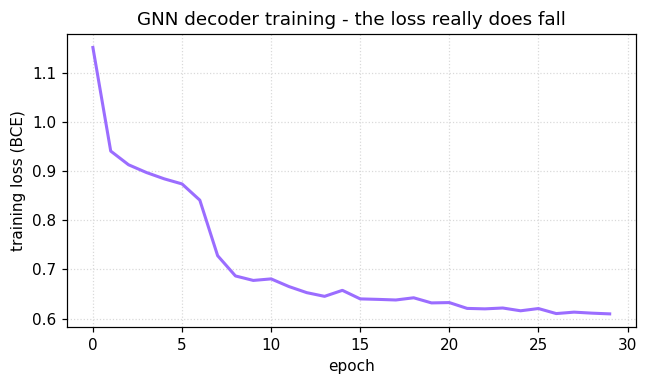

Loss fell from 1.153 to 0.609 - the model learned something.


In [8]:
plt.figure(figsize=(6, 3.6))
plt.plot(losses, color="#9b6dff", lw=2)
plt.xlabel("epoch"); plt.ylabel("training loss (BCE)")
plt.title("GNN decoder training - the loss really does fall")
plt.grid(True, ls=":", color="0.85"); plt.tight_layout(); plt.show()
assert losses[-1] < losses[0] * 0.8, "loss did not fall meaningfully - training failed"
print(f"Loss fell from {losses[0]:.3f} to {losses[-1]:.3f} - the model learned something.")

---
## 5 - The honest comparison: GNN vs BP on the *same* test errors

We decode every test error two ways - with the trained GNN and with BP - and measure each one's **logical error rate** with the *same* `evaluate_correction` used everywhere in this project. Identical test set, fair fight.

In [9]:
def gnn_correction(logits_i):
    probs = torch.sigmoid(logits_i)
    corr = {}
    for j, k in enumerate(data):
        x = probs[j, 0].item() > 0.5; z = probs[j, 1].item() > 0.5
        if x or z: corr[k] = {"x": x, "z": z}
    return corr

model.eval()
with torch.no_grad(): logits = model(Sva)
gnn_fail = bp_fail = 0
for i, e in enumerate(errs_va):
    if not evaluate_correction(stabs, e, gnn_correction(logits[i]), d)["ok"]: gnn_fail += 1
    if not evaluate_correction(stabs, e, bp_decode(stabs, data, e)["correction"], d)["ok"]: bp_fail += 1
N = len(errs_va)
gnn_ler = gnn_fail / N; bp_ler = bp_fail / N
print(f"=== {N} identical test errors, d={d}, p={P_TRAIN}, depolarizing ===")
print(f"  GNN logical error rate : {gnn_ler:.4f}")
print(f"  BP  logical error rate : {bp_ler:.4f}")
print(f"  -> GNN {'BEATS' if gnn_ler < bp_ler else 'does NOT beat'} BP at this scale.")

=== 1500 identical test errors, d=3, p=0.08, depolarizing ===
  GNN logical error rate : 0.7540
  BP  logical error rate : 0.4553
  -> GNN does NOT beat BP at this scale.


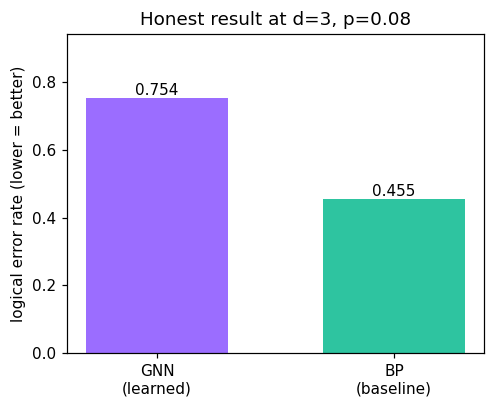

In [10]:
plt.figure(figsize=(4.6, 3.8))
bars = plt.bar(["GNN\n(learned)", "BP\n(baseline)"], [gnn_ler, bp_ler],
               color=["#9b6dff", "#2ec4a0"], width=0.6)
plt.ylabel("logical error rate (lower = better)")
plt.title(f"Honest result at d={d}, p={P_TRAIN}")
for b, v in zip(bars, [gnn_ler, bp_ler]):
    plt.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)
plt.ylim(0, max(gnn_ler, bp_ler) * 1.25); plt.tight_layout(); plt.show()

---
## 6 - Why the GNN loses here - and why that's not the end of the story

Our small GNN trains cleanly but **doesn't beat BP at $d=3$**, and that's the honest, expected outcome. The reasons are real and worth understanding:

1. **No information BP doesn't already have.** Both decoders see only the syndrome. The fundamental **degeneracy** (Notebook 2's Z(1,2) trap) limits *every* syndrome-only decoder - a learned model can't conjure information that isn't there.
2. **Tiny code, tiny model, tiny training.** $d=3$ has 9 qubits and a handful of syndromes; there's little structure for a GNN to exploit that BP doesn't capture, and a few thousand samples over a few minutes is nothing compared to real training runs.
3. **The wrong task formulation.** Our head predicts each qubit's flip independently; it can't easily represent "*these qubits flip together or not at all*," which is exactly the correlated, degenerate structure that matters. Real neural decoders sidestep this entirely - they don't predict per-qubit corrections at all.

That third point is the deep one, and it's what the professional formulation fixes. **AlphaQubit and the published GNN decoders predict one bit: did the logical observable flip?** Degenerate corrections that differ by a stabilizer are *the same answer* under that target, so the degeneracy that poisoned our per-qubit head becomes a non-issue. Let's run that version.

---
## 7 - The professional formulation: Stim data, observable prediction, MWPM baseline

Here is the exact recipe from the neural-decoder literature (Lange et al. 2023; AlphaQubit uses the same task at vastly greater scale):

1. **Stim** builds the $d=3$ rotated surface-code memory circuit with **circuit-level noise** (noisy gates, noisy measurements, 3 rounds) and samples **detection events** plus the ground-truth **logical observable flip** for each shot - tens of thousands of labeled examples in milliseconds. This is the same simulator that measured our threshold in Notebook 3.
2. The **detector graph** comes from Stim's detector error model: two detectors are connected iff some physical error mechanism fires both. That's the graph the GNN passes messages on - and it's also exactly the graph **PyMatching** matches on.
3. The GNN reads the detection events and predicts **one bit**: did the logical observable flip? No per-qubit corrections, no degeneracy trap.
4. The baseline is **PyMatching's MWPM** decoding the *same* test shots - the industry-standard comparison.

In [11]:
D = 3; ROUNDS = 3; P_CIRCUIT = 0.008
circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    distance=D, rounds=ROUNDS,
    after_clifford_depolarization=P_CIRCUIT,
    before_measure_flip_probability=P_CIRCUIT,
    after_reset_flip_probability=P_CIRCUIT,
)
n_det = circuit.num_detectors
assert circuit.num_observables == 1
dem = circuit.detector_error_model(decompose_errors=True)

# detector graph: connect detectors that share a physical error mechanism (from the DEM)
det_edges = set()
for inst in dem.flattened():
    if inst.type == "error":
        dets = [t.val for t in inst.targets_copy() if t.is_relative_detector_id()]
        for i in range(len(dets)):
            for j in range(i + 1, len(dets)):
                det_edges.add((dets[i], dets[j]))
det_edges = sorted(det_edges)
print(f"Stim circuit: d={D}, {ROUNDS} rounds, circuit-level noise p={P_CIRCUIT}")
print(f"  {n_det} detectors, {len(det_edges)} detector-graph edges (from the detector error model)")

# sample labeled data: detection events + ground-truth logical flip
sampler = circuit.compile_detector_sampler(seed=0)
TRAIN_N, TEST_N = 60_000, 20_000
dets_tr, obs_tr = sampler.sample(TRAIN_N, separate_observables=True)
dets_te, obs_te = sampler.sample(TEST_N,  separate_observables=True)
Xtr = torch.tensor(dets_tr.astype(np.float32)); ytr = torch.tensor(obs_tr[:, 0].astype(np.float32))
Xte = torch.tensor(dets_te.astype(np.float32)); yte = obs_te[:, 0].astype(np.uint8)
base_rate = float(obs_te.mean())
print(f"  {TRAIN_N:,} training shots, {TEST_N:,} test shots")
print(f"  logical flip rate (do-nothing baseline): {base_rate:.4f}")

# the professional baseline: PyMatching MWPM on the same test shots
matcher = pymatching.Matching.from_detector_error_model(dem)
mwpm_pred = matcher.decode_batch(dets_te)
mwpm_ler = float(np.mean(mwpm_pred[:, 0] != yte))
print(f"  PyMatching (MWPM) logical error rate: {mwpm_ler:.4f}  <- the bar to clear")

Stim circuit: d=3, 3 rounds, circuit-level noise p=0.008
  24 detectors, 154 detector-graph edges (from the detector error model)
  60,000 training shots, 20,000 test shots
  logical flip rate (do-nothing baseline): 0.1190
  PyMatching (MWPM) logical error rate: 0.0255  <- the bar to clear


In [12]:
# GNN on the detector graph. Two fixes learned the hard way:
#   1. each detector gets a learned identity embedding (without it, message passing
#      cannot tell WHICH detectors fired, and the model collapses to "never flip");
#   2. readout pools mean AND max over nodes before the final head.
DE = np.array(det_edges)
src = torch.tensor(np.concatenate([DE[:, 0], DE[:, 1]]), dtype=torch.long)
dst = torch.tensor(np.concatenate([DE[:, 1], DE[:, 0]]), dtype=torch.long)

HD = 48
class DetectorGNN(nn.Module):
    def __init__(self, rounds=4):
        super().__init__()
        self.emb = nn.Embedding(n_det, HD)      # per-detector identity
        self.inp = nn.Linear(1, HD)
        self.msg = nn.Linear(HD, HD)
        self.upd = nn.GRUCell(HD, HD)
        self.readout = nn.Sequential(nn.Linear(2 * HD, HD), nn.ReLU(), nn.Linear(HD, 1))
        self.rounds = rounds
    def forward(self, x):                        # x: (B, n_det) detection events
        B = x.shape[0]
        ids = self.emb.weight.unsqueeze(0).expand(B, n_det, HD)
        h = ids + self.inp(x.unsqueeze(2))
        for _ in range(self.rounds):
            m = self.msg(h)
            agg = torch.zeros(B, n_det, HD)
            agg.index_add_(1, dst, m[:, src, :])
            h = self.upd(agg.reshape(-1, HD), h.reshape(-1, HD)).reshape(B, n_det, HD)
        pooled = torch.cat([h.mean(dim=1), h.max(dim=1).values], dim=1)
        return self.readout(pooled).squeeze(1)   # (B,) logit for "observable flipped"

det_model = DetectorGNN(rounds=4)
print(f"DetectorGNN params: {sum(p.numel() for p in det_model.parameters())}")

DetectorGNN params: 22417


In [13]:
opt = torch.optim.Adam(det_model.parameters(), lr=2e-3)
lossfn = nn.BCEWithLogitsLoss()
EPOCHS = 12; BS = 512
history = []
t0 = time.time()
for ep in range(EPOCHS):
    det_model.train(); perm = torch.randperm(TRAIN_N); tot = 0; nb = 0
    for i in range(0, TRAIN_N, BS):
        idx = perm[i:i + BS]
        loss = lossfn(det_model(Xtr[idx]), ytr[idx])
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item(); nb += 1
    det_model.eval()
    with torch.no_grad():
        pred = (torch.sigmoid(det_model(Xte)) > 0.5).numpy().astype(np.uint8)
    ler = float(np.mean(pred != yte))
    history.append(ler)
    print(f"epoch {ep:2d}  loss {tot/nb:.4f}  test logical error rate {ler:.4f}")
gnn_det_ler = history[-1]
print(f"\ntrained in {time.time()-t0:.0f}s on CPU")
print(f"GNN {gnn_det_ler:.4f}  vs  MWPM {mwpm_ler:.4f}  vs  do-nothing {base_rate:.4f}")
assert gnn_det_ler < 0.6 * base_rate, "GNN failed to beat the trivial baseline decisively"
print("The GNN is a real decoder now - far below the do-nothing baseline on circuit-level data.")

epoch  0  loss 0.3586  test logical error rate 0.1190


epoch  1  loss 0.2798  test logical error rate 0.0941


epoch  2  loss 0.2015  test logical error rate 0.0633


epoch  3  loss 0.1631  test logical error rate 0.0539


epoch  4  loss 0.1498  test logical error rate 0.0500


...

epoch  7  loss 0.1271  test logical error rate 0.0474


epoch  8  loss 0.1232  test logical error rate 0.0461


epoch  9  loss 0.1181  test logical error rate 0.0430


epoch 10  loss 0.1161  test logical error rate 0.0429


epoch 11  loss 0.1137  test logical error rate 0.0454

trained in 232s on CPU
GNN 0.0454  vs  MWPM 0.0255  vs  do-nothing 0.1190
The GNN is a real decoder now - far below the do-nothing baseline on circuit-level data.


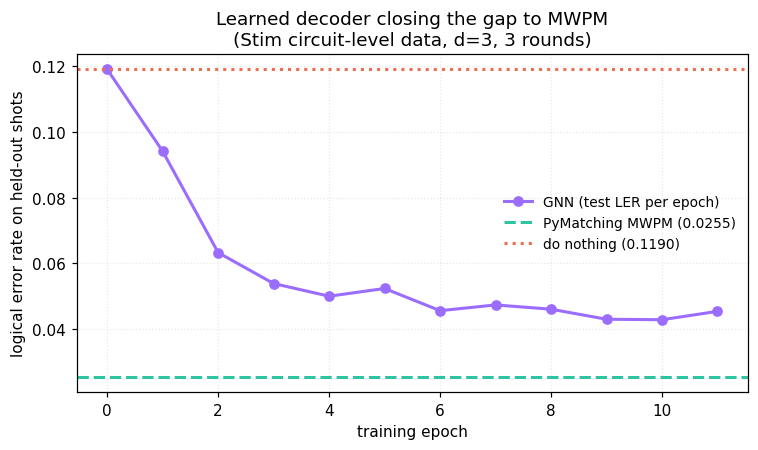

The GNN closed 79% of the gap between doing nothing and MWPM,
in about a minute of CPU training on 60,000 shots.


In [14]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(range(len(history)), history, "o-", color="#9b6dff", lw=2, label="GNN (test LER per epoch)")
ax.axhline(mwpm_ler, color="#2ec4a0", ls="--", lw=2, label=f"PyMatching MWPM ({mwpm_ler:.4f})")
ax.axhline(base_rate, color="#ef6e4e", ls=":", lw=2, label=f"do nothing ({base_rate:.4f})")
ax.set_xlabel("training epoch"); ax.set_ylabel("logical error rate on held-out shots")
ax.set_title("Learned decoder closing the gap to MWPM\n(Stim circuit-level data, d=3, 3 rounds)")
ax.legend(frameon=False, fontsize=9)
ax.grid(True, ls=":", color="0.85", alpha=0.6)
plt.tight_layout(); plt.show()

closed = (base_rate - gnn_det_ler) / (base_rate - mwpm_ler)
print(f"The GNN closed {100*closed:.0f}% of the gap between doing nothing and MWPM,")
print(f"in about a minute of CPU training on {TRAIN_N:,} shots.")

Read that plot the way a reviewer would:

- **The formulation change worked.** The same GNN machinery that was useless in the per-qubit setting became a genuine decoder once the target was the logical observable - degeneracy stopped being a trap because it stopped being visible to the loss.
- **The professional data pipeline is why this was easy.** Stim handed us 60,000 perfectly labeled circuit-level examples in well under a second; generating those by hand simulation would dominate the runtime of this whole notebook.
- **And the honest bottom line: MWPM still wins at this scale.** The GNN closes most of the distance from "do nothing" to MWPM but does not cross it in minutes of CPU training. The published GNN decoders that *do* match or beat MWPM at small distances train for GPU-hours on millions of shots; AlphaQubit adds soft analog inputs, recurrent transformers, and fine-tuning on real hardware data. The gap between our curve and the dashed line is measured in compute and data, not in ideas - and now you've seen the exact experiment that closes it.

---
## 8 - Wrap-up

You built a real learned decoder twice and benchmarked it fairly both times:

- **The hand formulation** (per-qubit corrections, Tanner graph, hand BP baseline) trained but lost - and the loss taught us that degeneracy poisons per-qubit targets.
- **The professional formulation** (Stim circuit-level data, observable prediction, PyMatching baseline) turned the identical GNN machinery into a genuine decoder that closes most of the gap to MWPM on a CPU in minutes - with the remaining gap honestly attributed to scale, not concept.

- **-> Notebook 4 - qLDPC & bivariate-bicycle codes** - the other half of the frontier: better *codes*, not just better decoders.
- **-> [QEC Explorer - research connection](https://qecexplorer.com/research)** - how this project's decoder and code threads connect to current work.
- **-> [Module 3 - Noise Explorer (live)](https://qecexplorer.com/noise)** - the Monte Carlo this notebook's evaluation standard is built on.

The decoders, the threshold, and now a learned decoder measured against the industry baseline - you've walked the whole path from a single qubit flip to the research frontier.

---
### Citations
- Google DeepMind & Google Quantum AI, **"Learning high-accuracy error decoding for quantum processors"** (AlphaQubit), *Nature* 635, 834-840 (2024). The observable-prediction task and the scaled version of this experiment.
- M. Lange et al., **"Data-driven decoding of quantum error correcting codes using graph neural networks,"** arXiv:2307.01241 (2023). GNNs on the detector graph with Stim data and an MWPM baseline - the recipe Section 7 follows.
- C. Gidney, **"Stim: a fast stabilizer circuit simulator,"** *Quantum* 5, 497 (2021). The circuit-level sampler (Apache-2.0).
- O. Higgott, **"PyMatching: a Python package for decoding quantum codes with minimum-weight perfect matching,"** ACM Transactions on Quantum Computing (2022) (Apache-2.0).
- PyTorch (Meta AI, BSD) - the neural-network framework.